# A State-of-the-Art Framework for Used Car Price Prediction demonstrating a 9.4% reduction in the RMSE using a fine-tuned XGBoost Regressor

# Phase 1: Data Preprocessing and EDA

## Step 1: Data Loading and Inspection

In [13]:
import pandas as pd
import glob
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

print("--- Phase 1, Step 1 (REVISED): Data Loading & Brand Creation ---")

# --- 1. Define Path and Find Files ---
data_path = r"D:\vit_projects\ml_project\dataset\used_cars"
csv_pattern = os.path.join(data_path, "*.csv")
file_list = glob.glob(csv_pattern)

if not file_list:
    print(f"Error: No CSV files found in the directory: {data_path}")
else:
    print(f"Found {len(file_list)} CSV files. Loading, adding 'brand', and combining...")
    
    df_list = []
    
    # --- 2. Load, Add Brand, and Combine Files ---
    for file in file_list:
        try:
            # Load the CSV file
            df_temp = pd.read_csv(file)
            
            # --- THIS IS THE NEW/IMPORTANT PART ---
            # Get the filename (e.g., "audi.csv")
            filename = os.path.basename(file)
            # Get the brand (e.g., "audi") and capitalize it ("Audi")
            # Note: This handles "hyundi" -> "Hyundi". We'll fix it later.
            brand_name = filename.split('.')[0].capitalize()
            
            # Add the 'brand' column
            df_temp['brand'] = brand_name
            # --- END OF NEW PART ---
            
            print(f"  > Loaded {file} ({df_temp.shape[0]} rows). Added 'brand': {brand_name}")
            df_list.append(df_temp)
            
        except Exception as e:
            print(f"  > Error loading {file}: {e}")

    if not df_list:
        print("Error: No dataframes were successfully loaded. Cannot proceed.")
    else:
        # Combine all DataFrames into one
        df = pd.concat(df_list, ignore_index=True)
        print(f"\nSuccessfully combined all files into a single DataFrame.")
        
        # --- 3. Initial Inspection (of new DataFrame) ---
        print("\n--- 3a. Combined DataFrame Shape ---")
        # We expect 11 columns now: 10 original + 1 'brand'
        print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}") 

        print("\n--- 3b. First 5 Rows (df.head()) ---")
        print(df.head())

        print("\n--- 3c. Data Types & Non-Null Counts (df.info()) ---")
        df.info()

        print("\n--- 3d. Missing Values Count (df.isnull().sum()) ---")
        print(df.isnull().sum())
        
        print("\n--- 3e. Check Brand Column Values (df['brand'].unique()) ---")
        print(f"Brands loaded: {df['brand'].unique()}")

        print("\n--- Revised Step 1 Complete ---")
        print("Please copy the entire output and paste it in your reply.")
        print("This output is crucial for building the *real* Step 2: Data Cleaning.")

--- Phase 1, Step 1 (REVISED): Data Loading & Brand Creation ---
Found 9 CSV files. Loading, adding 'brand', and combining...
  > Loaded D:\vit_projects\ml_project\dataset\used_cars\audi.csv (10668 rows). Added 'brand': Audi
  > Loaded D:\vit_projects\ml_project\dataset\used_cars\bmw.csv (10781 rows). Added 'brand': Bmw
  > Loaded D:\vit_projects\ml_project\dataset\used_cars\ford.csv (17965 rows). Added 'brand': Ford
  > Loaded D:\vit_projects\ml_project\dataset\used_cars\hyundi.csv (4860 rows). Added 'brand': Hyundi
  > Loaded D:\vit_projects\ml_project\dataset\used_cars\merc.csv (13119 rows). Added 'brand': Merc
  > Loaded D:\vit_projects\ml_project\dataset\used_cars\skoda.csv (6267 rows). Added 'brand': Skoda
  > Loaded D:\vit_projects\ml_project\dataset\used_cars\toyota.csv (6738 rows). Added 'brand': Toyota
  > Loaded D:\vit_projects\ml_project\dataset\used_cars\vauxhall.csv (13632 rows). Added 'brand': Vauxhall
  > Loaded D:\vit_projects\ml_project\dataset\used_cars\vw.csv (15157

## Step 2: Data Cleaning

In [14]:
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

if 'df' not in locals():
    print("Error: 'df' DataFrame not found.")
    print("Please re-run the Step 1 code first.")
else:
    print("--- Phase 1, Step 2: Data Cleaning ---")
    
    print(f"Original shape: {df.shape}")
    
    # --- 1. Merge 'tax' and 'tax(£)' ---
    print("\n1. Merging 'tax' and 'tax(£)' columns...")
    # Use fillna() to fill missing 'tax' values with values from 'tax(£)'
    df['tax'] = df['tax'].fillna(df['tax(£)'])
    
    # Now drop the redundant 'tax(£)' column
    df = df.drop('tax(£)', axis=1)
    print("  > Merged 'tax' and 'tax(£)'. Dropped 'tax(£)'.")
    
    # --- 2. Remove Duplicate Rows ---
    print("\n2. Removing duplicate rows...")
    rows_before = df.shape[0]
    df = df.drop_duplicates()
    rows_after = df.shape[0]
    print(f"  > Removed {rows_before - rows_after} duplicate rows.")
    
    # --- 3. Standardize Brand Names ---
    print("\n3. Standardizing brand names...")
    brand_replacements = {
        'Bmw': 'BMW',
        'Hyundi': 'Hyundai',
        'Merc': 'Mercedes-Benz',
        'Vw': 'Volkswagen'
    }
    df['brand'] = df['brand'].replace(brand_replacements)
    print(f"  > Standardized brand names. Unique brands now: {df['brand'].unique()}")
    
    # --- 4. Clean Invalid 'year' Values ---
    print("\n4. Cleaning 'year' column...")
    rows_before = df.shape[0]
    # Remove future/impossible years (like 2060)
    # Let's assume the dataset is from around 2020-2021
    current_year_plus_buffer = 2024
    df = df[df['year'] <= current_year_plus_buffer]
    
    # Remove extremely old outliers (like 1970)
    # Let's set a reasonable floor of 1995 for a "used car" market
    df = df[df['year'] >= 1995]
    rows_after = df.shape[0]
    print(f"  > Removed {rows_before - rows_after} rows with invalid years (e.g., >{current_year_plus_buffer} or <1995).")
    print(f"  > Year range is now: {df['year'].min()} - {df['year'].max()}")

    # --- 5. Clean 'engineSize' and 'mpg' ---
    print("\n5. Cleaning 'engineSize' and 'mpg'...")
    
    # First, let's see which fuelTypes have engineSize == 0
    print("  > Checking 'engineSize' = 0.0:")
    fueltypes_with_zero_engine = df[df['engineSize'] == 0.0]['fuelType'].unique()
    print(f"    Fuel types with 0.0 engineSize: {fueltypes_with_zero_engine}")
    
    # Remove rows where engineSize is 0 but fuelType is clearly 'Petrol' or 'Diesel'
    rows_before = df.shape[0]
    impossible_engine = (df['engineSize'] == 0.0) & (df['fuelType'].isin(['Petrol', 'Diesel']))
    df = df[~impossible_engine] # ~ tilde means "not"
    rows_after = df.shape[0]
    print(f"  > Removed {rows_before - rows_after} rows with 0.0 engineSize for Petrol/Diesel.")
    
    # Now check and clean 'mpg'
    # Remove rows with impossibly low MPG (e.g., < 5)
    rows_before = df.shape[0]
    df = df[df['mpg'] >= 5]
    rows_after = df.shape[0]
    print(f"  > Removed {rows_before - rows_after} rows with 'mpg' < 5.")
    print(f"  > MPG range is now: {df['mpg'].min()} - {df['mpg'].max()}")
    
    # --- 6. Inspect Categorical Variables ---
    print("\n6. Inspecting categorical variables (unique values)...")
    
    # We will encode these later. For now, just inspect.
    print(f"  > 'transmission' unique: {df['transmission'].unique()}")
    print(f"  > 'fuelType' unique: {df['fuelType'].unique()}")
    
    # Check cardinality (number of unique values) for 'model'
    model_count = df['model'].nunique()
    print(f"  > 'model' unique count: {model_count}")
    if model_count > 50:
        print(f"    Note: 'model' has high cardinality ({model_count}). We will not use One-Hot Encoding.")
        print("    We will handle this in Step 4 (Feature Engineering) or before modeling.")
    
    # --- 7. Final Inspection ---
    print("\n--- 7a. Cleaned DataFrame Info (df.info()) ---")
    df.info()
    
    print("\n--- 7b. Cleaned DataFrame Missing Values (df.isnull().sum()) ---")
    # After merging tax and dropping invalid rows, we expect 0 nulls.
    print(df.isnull().sum())

    print("\n--- 7c. Cleaned DataFrame Statistics (df.describe()) ---")
    print(df.describe())
    
    print("\n--- 7d. Cleaned DataFrame Head (df.head()) ---")
    print(df.head())
    
    print("\n--- Step 2 Complete ---")
    print("Please copy the entire output from this script and paste it in your reply.")
    print("We need to confirm all missing values are handled before moving to Outliers (Step 3).")

--- Phase 1, Step 2: Data Cleaning ---
Original shape: (99187, 11)

1. Merging 'tax' and 'tax(£)' columns...
  > Merged 'tax' and 'tax(£)'. Dropped 'tax(£)'.

2. Removing duplicate rows...
  > Removed 1475 duplicate rows.

3. Standardizing brand names...
  > Standardized brand names. Unique brands now: ['Audi' 'BMW' 'Ford' 'Hyundai' 'Mercedes-Benz' 'Skoda' 'Toyota' 'Vauxhall'
 'Volkswagen']

4. Cleaning 'year' column...
  > Removed 3 rows with invalid years (e.g., >2024 or <1995).
  > Year range is now: 1996 - 2020

5. Cleaning 'engineSize' and 'mpg'...
  > Checking 'engineSize' = 0.0:
    Fuel types with 0.0 engineSize: ['Petrol' 'Diesel' 'Hybrid' 'Electric' 'Other']
  > Removed 226 rows with 0.0 engineSize for Petrol/Diesel.
  > Removed 18 rows with 'mpg' < 5.
  > MPG range is now: 5.5 - 470.8

6. Inspecting categorical variables (unique values)...
  > 'transmission' unique: ['Manual' 'Automatic' 'Semi-Auto' 'Other']
  > 'fuelType' unique: ['Petrol' 'Diesel' 'Hybrid' 'Other' 'Electri

## Step 3: Feature Engineering

In [15]:
import pandas as pd

if 'df' not in locals():
    print("Error: 'df' DataFrame not found.")
    print("Please make sure you have the 'df' from the previous step in memory.")
else:
    print("--- Phase 1, Step 3: Feature Engineering ---")
    
    current_year_proxy = 2021
    df['car_age'] = current_year_proxy - df['year']
    
    print(f"Created 'car_age' feature using {current_year_proxy} as the reference.")

    # 2. Drop the original 'year' column
    df = df.drop('year', axis=1)
    print("Dropped the original 'year' column.")
    
    # 3. Inspect the new DataFrame
    print("\n--- 3a. DataFrame Head with 'car_age' ---")
    print(df.head())
    
    print("\n--- 3b. DataFrame Info ---")
    df.info()
    
    print("\n--- 3c. DataFrame Statistics (note the new 'car_age' column) ---")
    print(df.describe())
    
    print("\n--- Step 3 Complete ---")
    print("Please copy the entire output and paste it in your reply.")
    print("Next, we will perform the (new) Step 4: Outlier Detection and Correction.")

--- Phase 1, Step 3: Feature Engineering ---
Created 'car_age' feature using 2021 as the reference.
Dropped the original 'year' column.

--- 3a. DataFrame Head with 'car_age' ---
  model  price transmission  mileage fuelType    tax   mpg  engineSize brand  car_age
0    A1  12500       Manual    15735   Petrol  150.0  55.4         1.4  Audi        4
1    A6  16500    Automatic    36203   Diesel   20.0  64.2         2.0  Audi        5
2    A1  11000       Manual    29946   Petrol   30.0  55.4         1.4  Audi        5
3    A4  16800    Automatic    25952   Diesel  145.0  67.3         2.0  Audi        4
4    A3  17300       Manual     1998   Petrol  145.0  49.6         1.0  Audi        2

--- 3b. DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 97465 entries, 0 to 99186
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         97465 non-null  object 
 1   price         97465 non-null  int64  
 

## Step 4: Outlier Detection and Correction

--- Phase 1, Step 4: Outlier Detection and Correction ---

--- 1. Displaying Box Plots BEFORE Outlier Correction ---

Saved '1_boxplots_before_correction.png' to D:\vit_projects\ml_project\dataset\used_cars
Displaying plots... (you may need to close the plot window to continue)


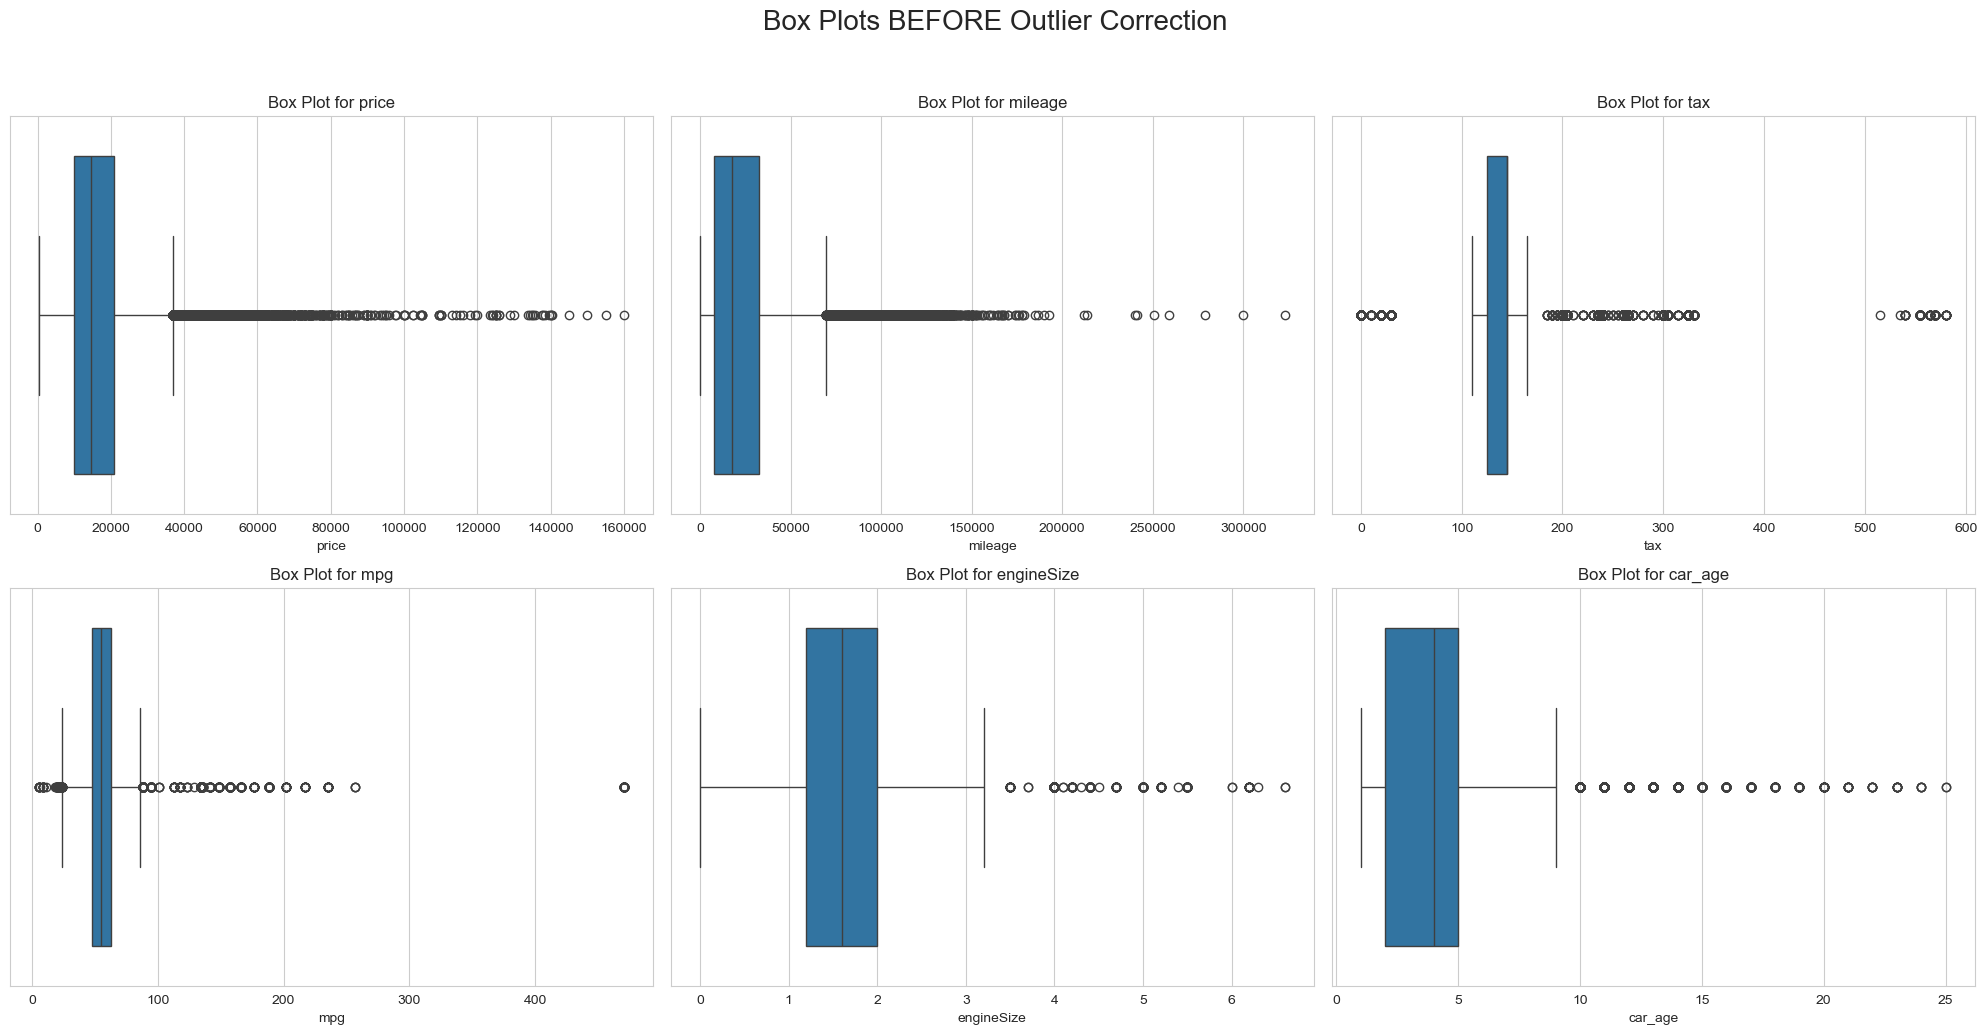


--- 2. Correcting Outliers by Capping (Winsorizing) ---

Processing column: price
  Q1: 9999.00, Q3: 20750.00, IQR: 10751.00
  Calculated Lower Bound: -6127.50
  Calculated Upper Bound: 36876.50
  Effective Lower Bound (respecting min val 450): 450.00
  > Found 0 lower outliers (will be capped to 450.00)
  > Found 3808 upper outliers (will be capped to 36876.50)

Processing column: mileage
  Q1: 7680.00, Q3: 32505.00, IQR: 24825.00
  Calculated Lower Bound: -29557.50
  Calculated Upper Bound: 69742.50
  Effective Lower Bound (respecting min val 1): 1.00
  > Found 0 lower outliers (will be capped to 1.00)
  > Found 3832 upper outliers (will be capped to 69742.50)

Processing column: tax
  Q1: 125.00, Q3: 145.00, IQR: 20.00
  Calculated Lower Bound: 95.00
  Calculated Upper Bound: 175.00
  Effective Lower Bound (respecting min val 0.0): 95.00
  > Found 22907 lower outliers (will be capped to 95.00)
  > Found 5618 upper outliers (will be capped to 175.00)

Processing column: mpg
  Q1: 47

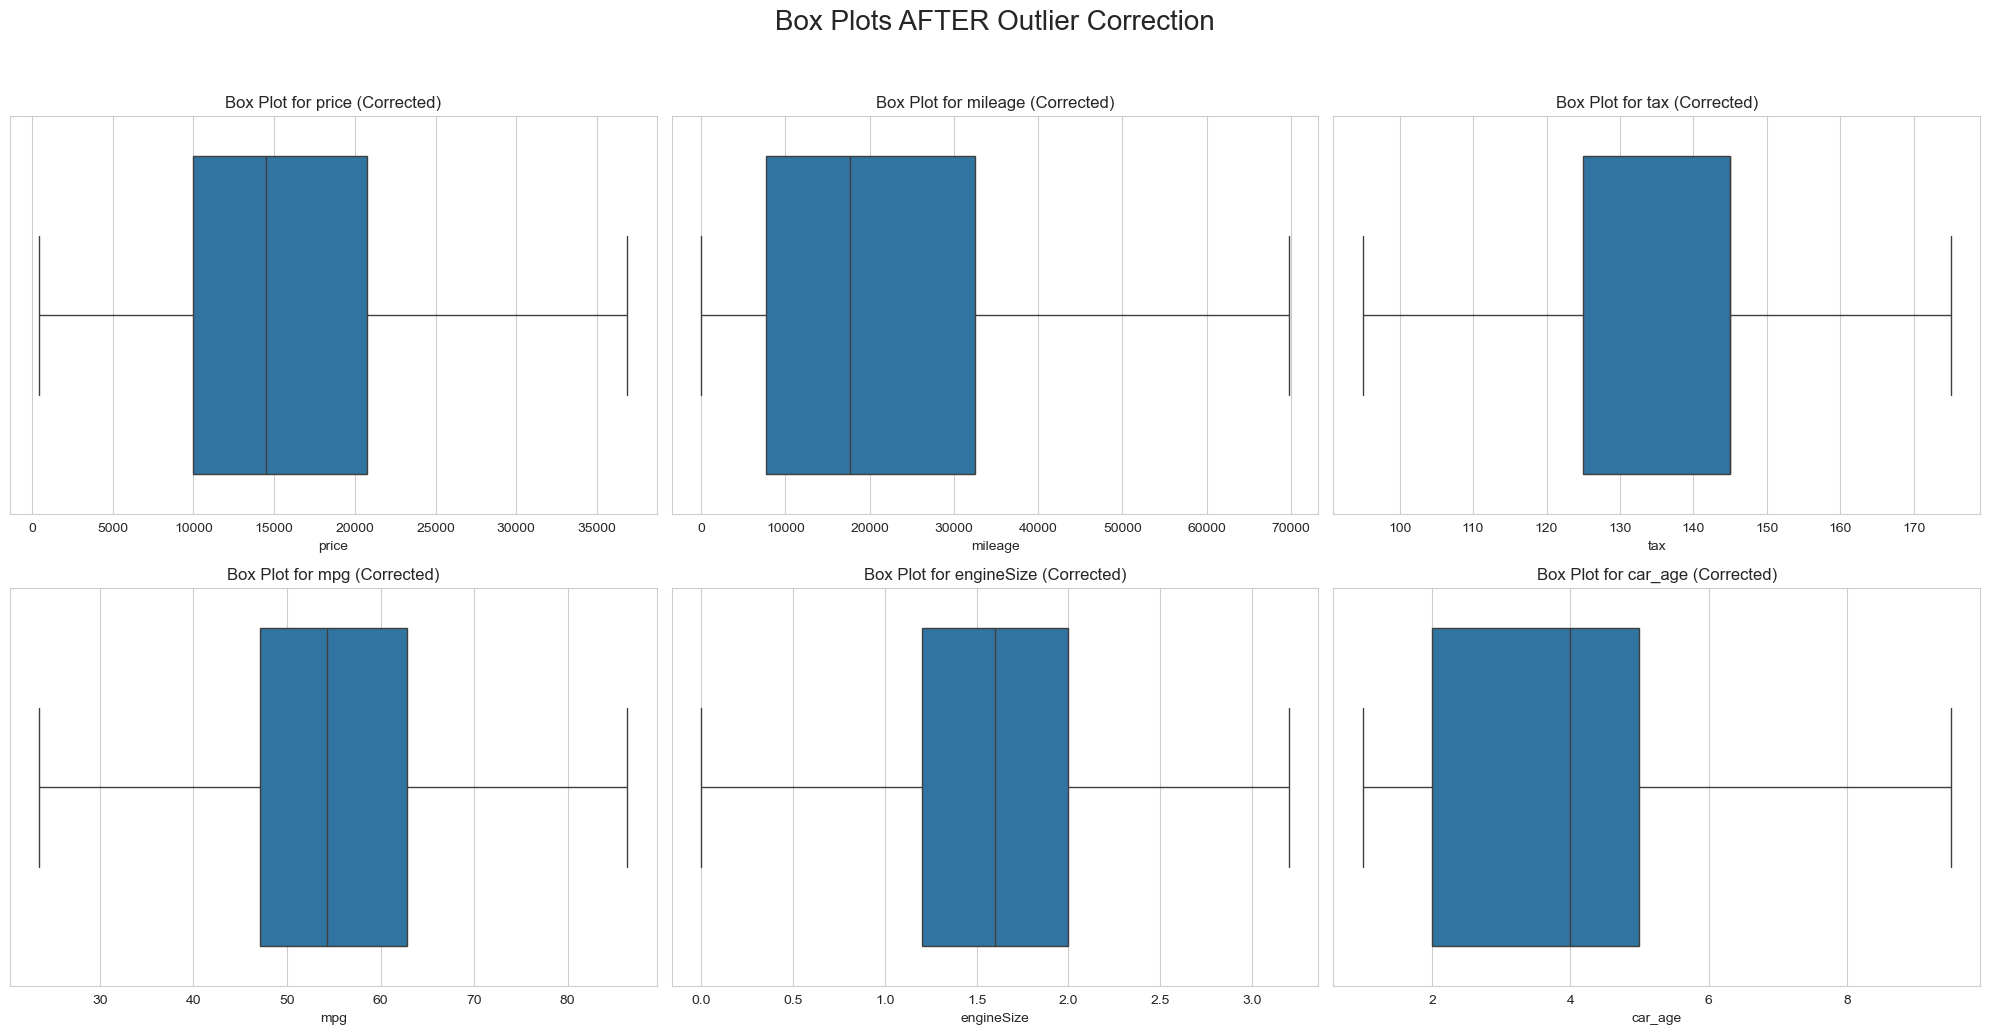


--- 4. Descriptive Statistics AFTER Outlier Correction ---
         price  mileage      tax      mpg  engineSize  car_age
count 97465.00 97465.00 97465.00 97465.00    97465.00 97465.00
mean  16312.68 22471.92   134.49    54.68        1.66     3.88
std    8149.89 18503.77    23.83    11.51        0.52     1.88
min     450.00     1.00    95.00    23.55        0.00     1.00
25%    9999.00  7680.00   125.00    47.10        1.20     2.00
50%   14475.00 17689.00   145.00    54.30        1.60     4.00
75%   20750.00 32505.00   145.00    62.80        2.00     5.00
max   36876.50 69742.50   175.00    86.35        3.20     9.50

--- Step 4 Complete ---
Please review the 'before' and 'after' plots and the new descriptive statistics.
Paste the text output (starting from '--- Phase 1, Step 4... ---') back to me.


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.float_format', lambda x: '%.2f' % x)

if 'df' not in locals():
    print("Error: 'df' DataFrame not found.")
    print("Please make sure you have the 'df' from the previous step in memory.")
else:
    print("--- Phase 1, Step 4: Outlier Detection and Correction ---")
    
    # Define the numerical columns to check
    # Note: We include 'tax' and 'engineSize' even with min 0, as the
    # IQR method will just calculate a lower bound (which might be < 0)
    # and we will cap it at the valid minimum (like 0).
    numeric_cols = ['price', 'mileage', 'tax', 'mpg', 'engineSize', 'car_age']

    # --- 1. Detect: Box Plots BEFORE Correction ---
    print("\n--- 1. Displaying Box Plots BEFORE Outlier Correction ---")
    plt.figure(figsize=(20, 10))
    plt.suptitle("Box Plots BEFORE Outlier Correction", fontsize=20, y=1.03)
    
    for i, col in enumerate(numeric_cols, 1):
        plt.subplot(2, 3, i)
        sns.boxplot(x=df[col])
        plt.title(f'Box Plot for {col}')
    
    plt.tight_layout()
    # Save the plot to your disk
    plt.savefig(os.path.join(data_path, "1_boxplots_before_correction.png"))
    print(f"\nSaved '1_boxplots_before_correction.png' to {data_path}")
    print("Displaying plots... (you may need to close the plot window to continue)")
    plt.show()

    
    # --- 2. Correct: Capping Outliers using IQR ---
    print("\n--- 2. Correcting Outliers by Capping (Winsorizing) ---")
    
    # Make a copy to see the effect of capping
    df_capped = df.copy()
    
    for col in numeric_cols:
        print(f"\nProcessing column: {col}")
        
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # --- Capping Logic ---
        
        # We must respect valid minimums (0 for tax/engineSize, 1 for mileage/age)
        # We take the MAXIMUM of the calculated lower_bound and the column's actual minimum
        valid_min = df_capped[col].min()
        lower_bound = max(lower_bound, valid_min)
        
        print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
        print(f"  Calculated Lower Bound: {Q1 - 1.5 * IQR:.2f}")
        print(f"  Calculated Upper Bound: {upper_bound:.2f}")
        print(f"  Effective Lower Bound (respecting min val {valid_min}): {lower_bound:.2f}")

        # Find outliers
        lower_outliers = (df_capped[col] < lower_bound).sum()
        upper_outliers = (df_capped[col] > upper_bound).sum()
        
        print(f"  > Found {lower_outliers} lower outliers (will be capped to {lower_bound:.2f})")
        print(f"  > Found {upper_outliers} upper outliers (will be capped to {upper_bound:.2f})")
        
        # Apply the capping using np.clip
        df_capped[col] = np.clip(df_capped[col], lower_bound, upper_bound)

    # Assign the capped DataFrame back to 'df'
    df = df_capped
    print("\n--- Outlier Capping Complete ---")

    
    # --- 3. Verify: Box Plots AFTER Correction ---
    print("\n--- 3. Displaying Box Plots AFTER Outlier Correction ---")
    plt.figure(figsize=(20, 10))
    plt.suptitle("Box Plots AFTER Outlier Correction", fontsize=20, y=1.03)
    
    for i, col in enumerate(numeric_cols, 1):
        plt.subplot(2, 3, i)
        sns.boxplot(x=df[col])
        plt.title(f'Box Plot for {col} (Corrected)')
    
    plt.tight_layout()
    # Save the plot to your disk
    plt.savefig(os.path.join(data_path, "2_boxplots_after_correction.png"))
    print(f"\nSaved '2_boxplots_after_correction.png' to {data_path}")
    print("Displaying plots... (you may need to close the plot window to continue)")
    plt.show()

    
    # --- 4. Final Check: Descriptive Statistics ---
    print("\n--- 4. Descriptive Statistics AFTER Outlier Correction ---")
    print(df.describe())
    
    print("\n--- Step 4 Complete ---")
    print("Please review the 'before' and 'after' plots and the new descriptive statistics.")
    print("Paste the text output (starting from '--- Phase 1, Step 4... ---') back to me.")

## Step 5: EDA (Univariate, Bivariate, Correlation analysis)

--- Phase 1, Step 5: Exploratory Data Analysis (EDA) ---

1. Generating Univariate Analysis plots...
  > Saved '3_univariate_histograms.png'
  > Saved '4_univariate_countplots.png'

2. Generating Bivariate Analysis plots (vs. Price)...
  > Saved '5_bivariate_scatter.png'
  > Saved '6_bivariate_boxplots.png'

3. Generating Correlation Heatmap...
  > Saved '7_correlation_heatmap.png'

--- Correlation Matrix (Raw Data) ---
            price  mileage   tax   mpg  engineSize  car_age
price        1.00    -0.48  0.35 -0.43        0.63    -0.57
mileage     -0.48     1.00 -0.31  0.28        0.11     0.77
tax          0.35    -0.31  1.00 -0.58        0.22    -0.34
mpg         -0.43     0.28 -0.58  1.00       -0.30     0.24
engineSize   0.63     0.11  0.22 -0.30        1.00     0.02
car_age     -0.57     0.77 -0.34  0.24        0.02     1.00

Displaying all plots... (you may need to close 4 plot windows)


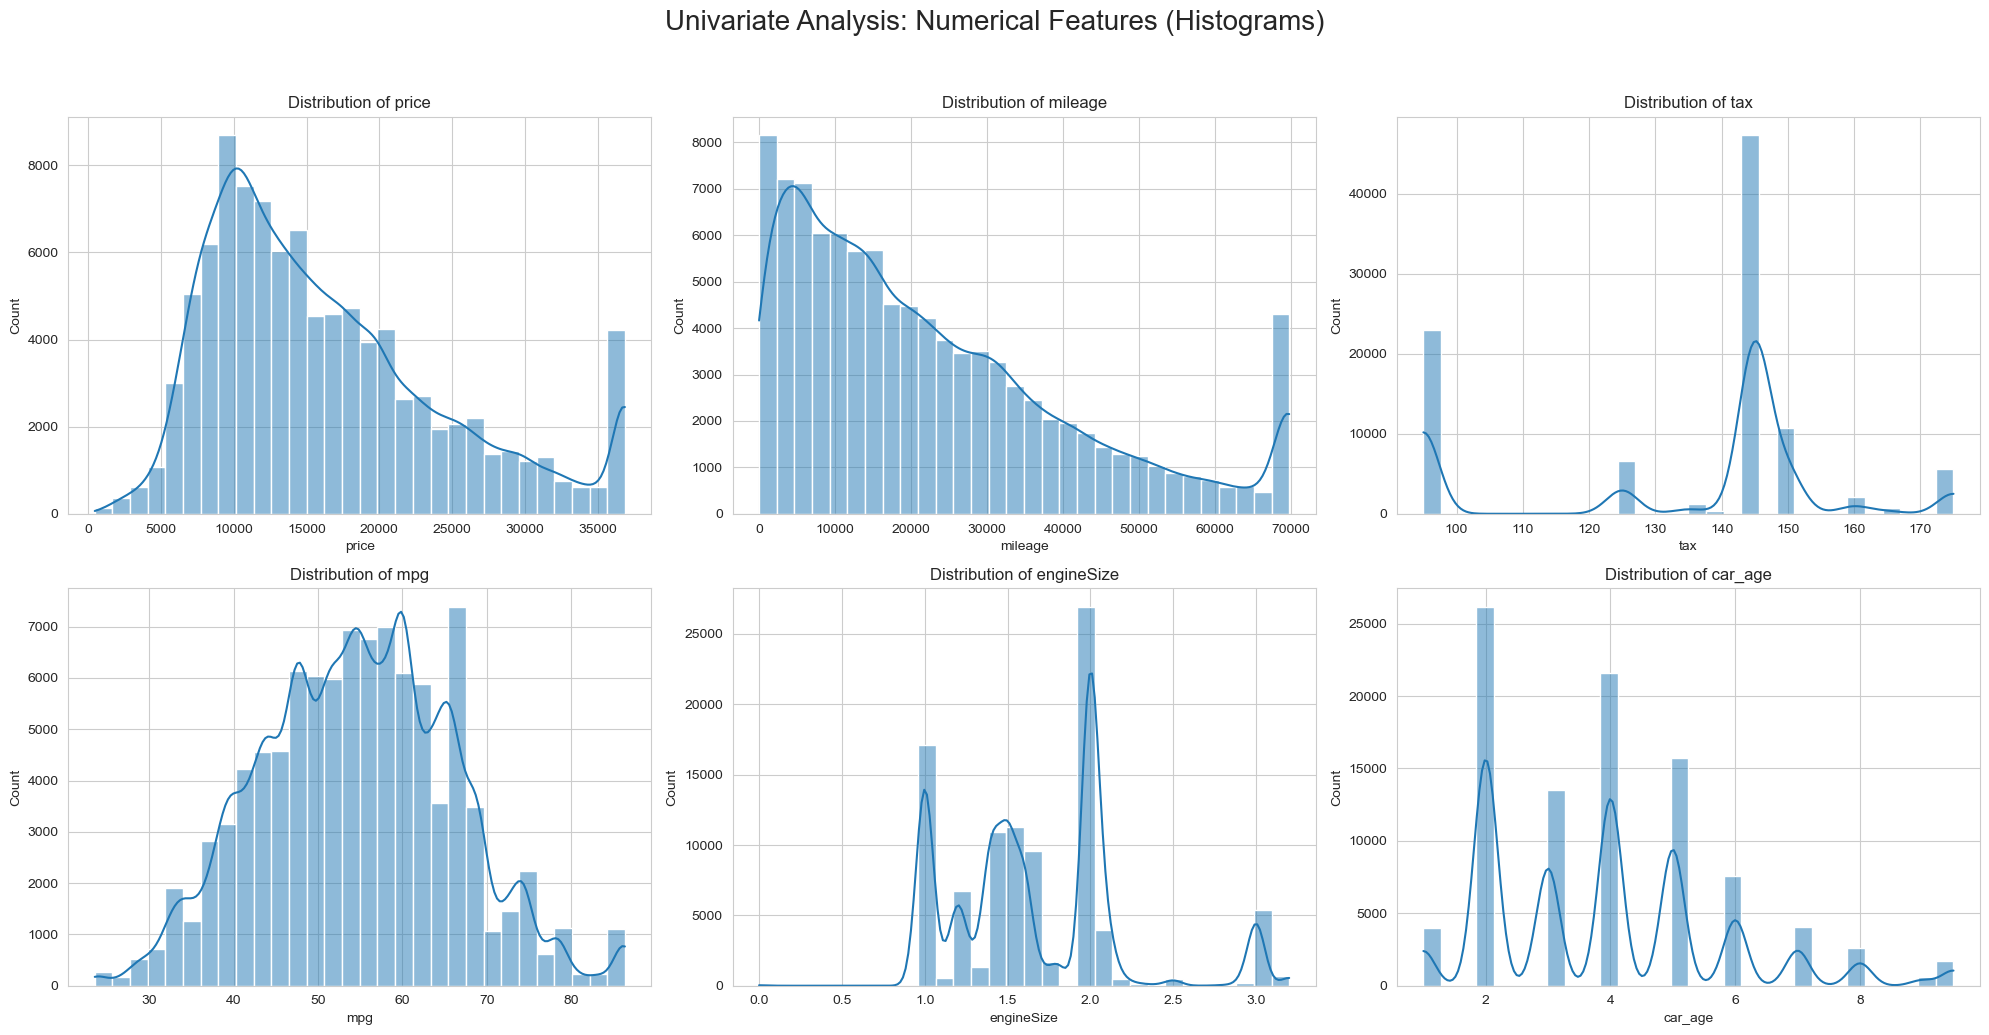

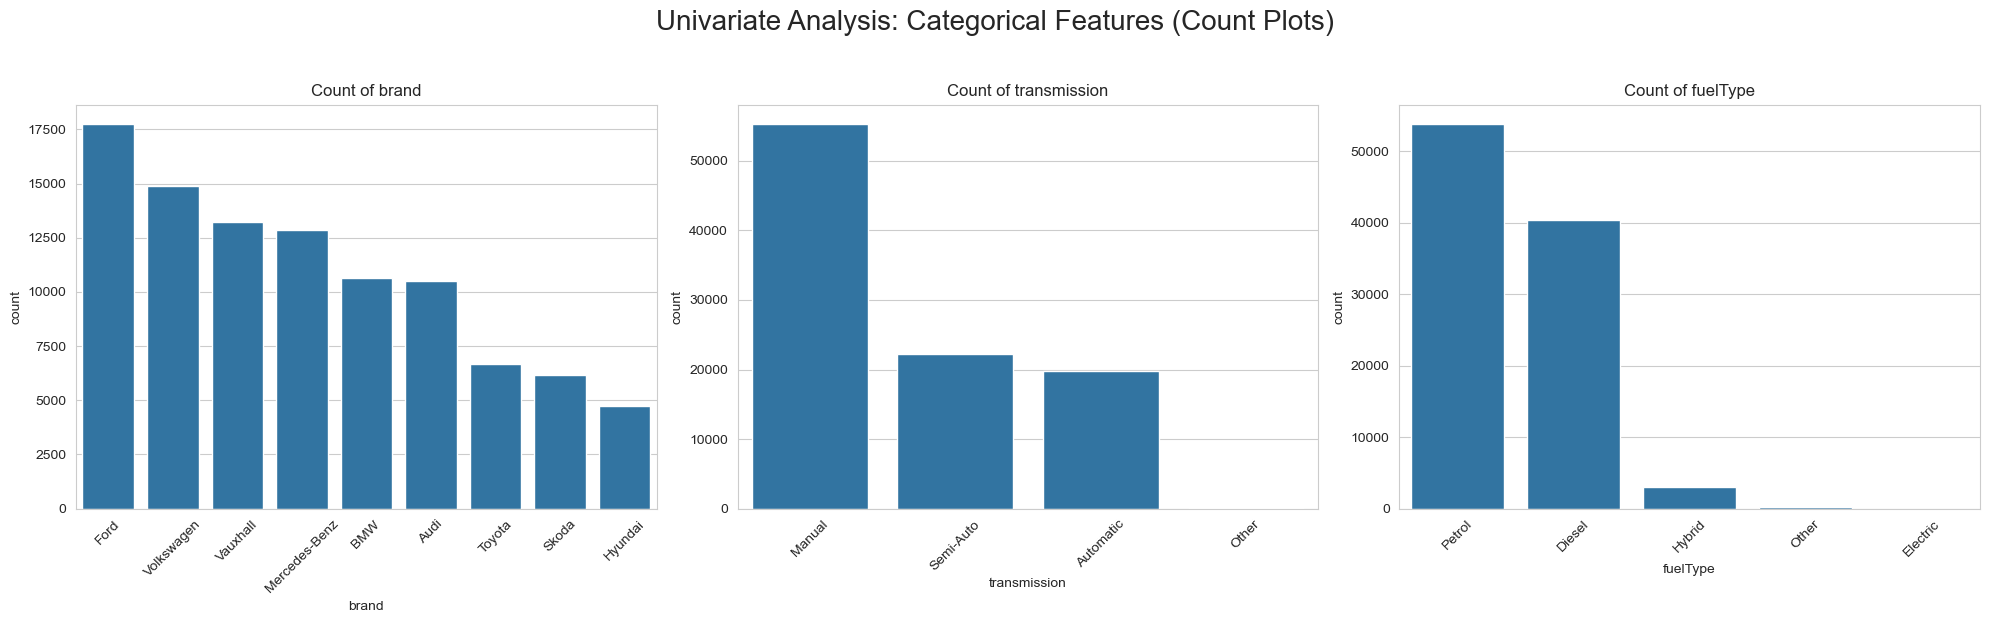

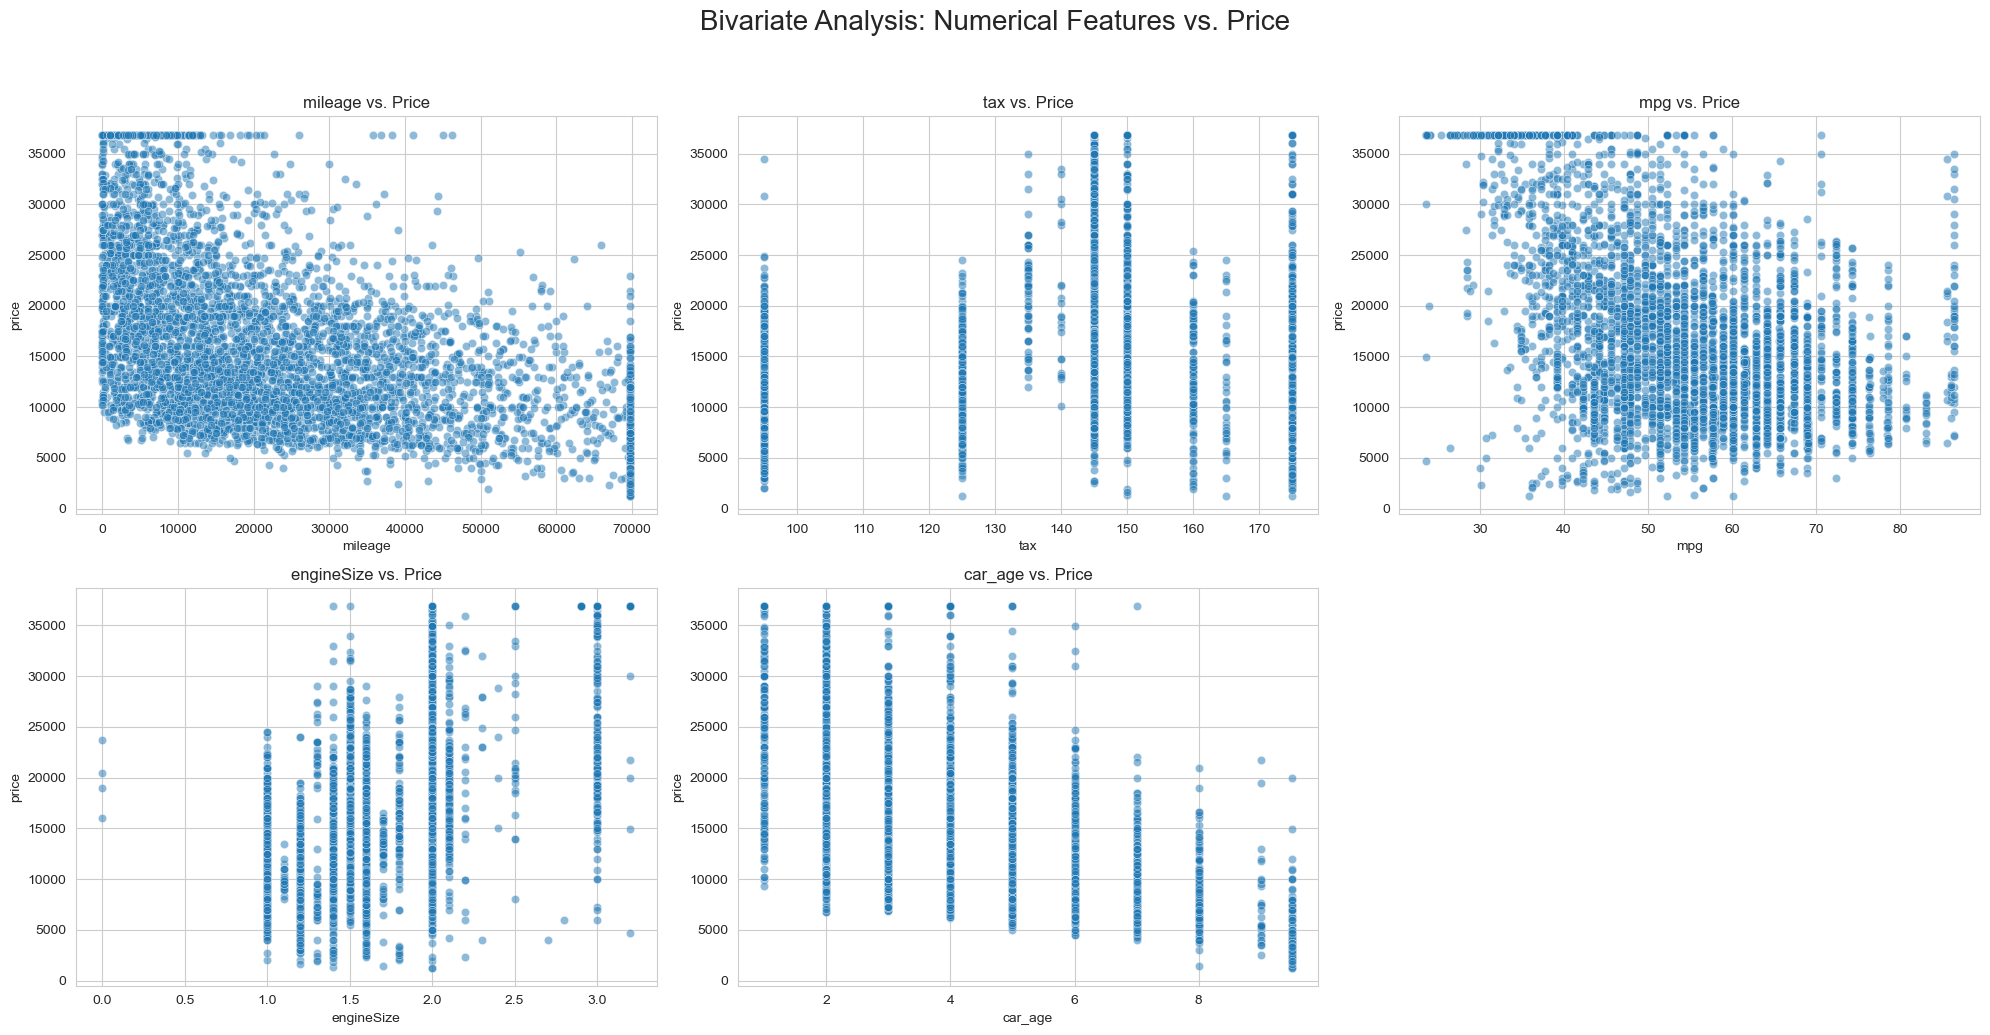

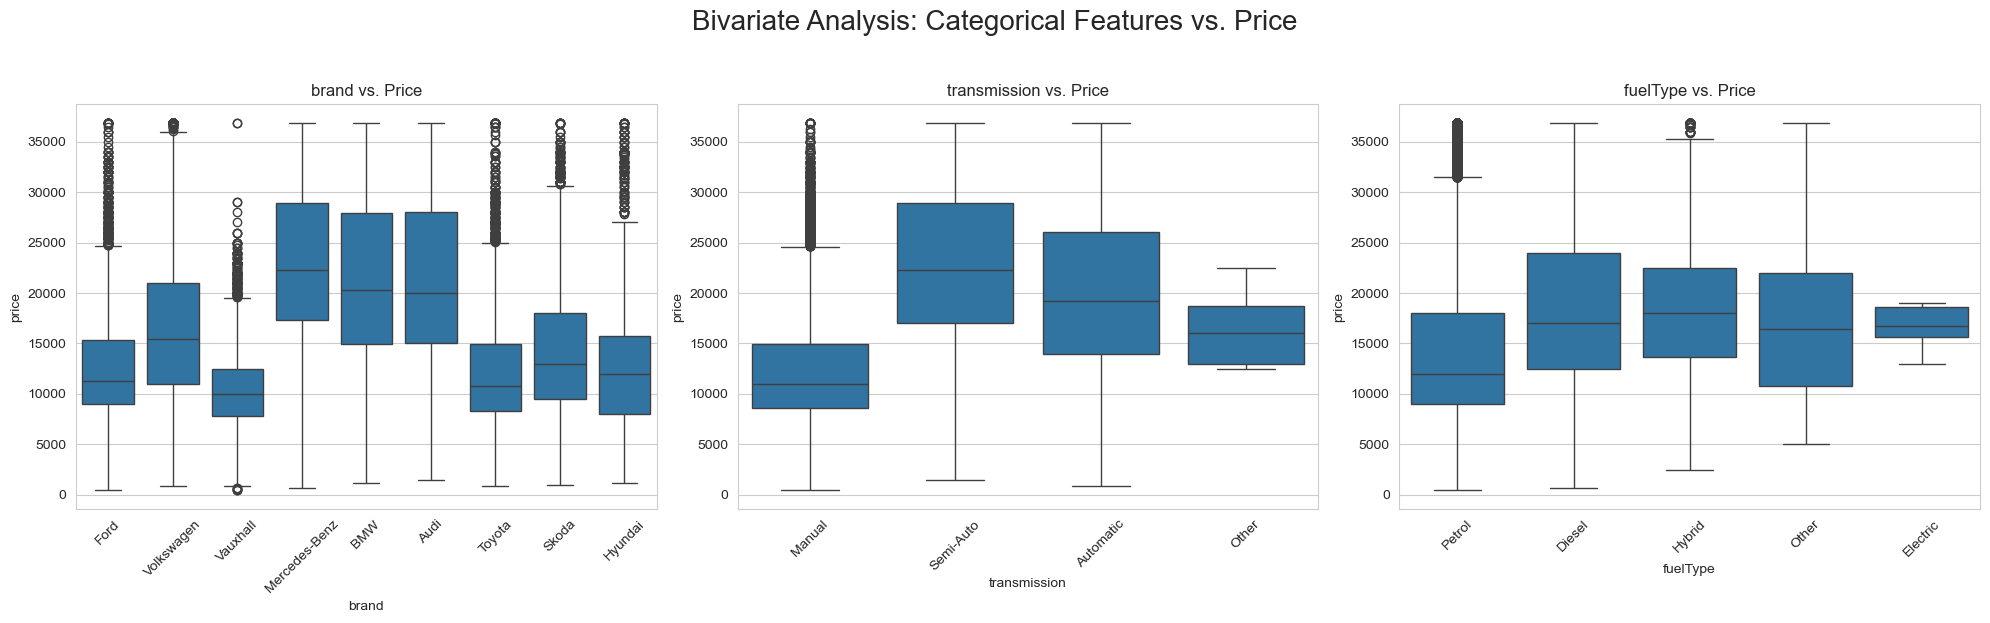

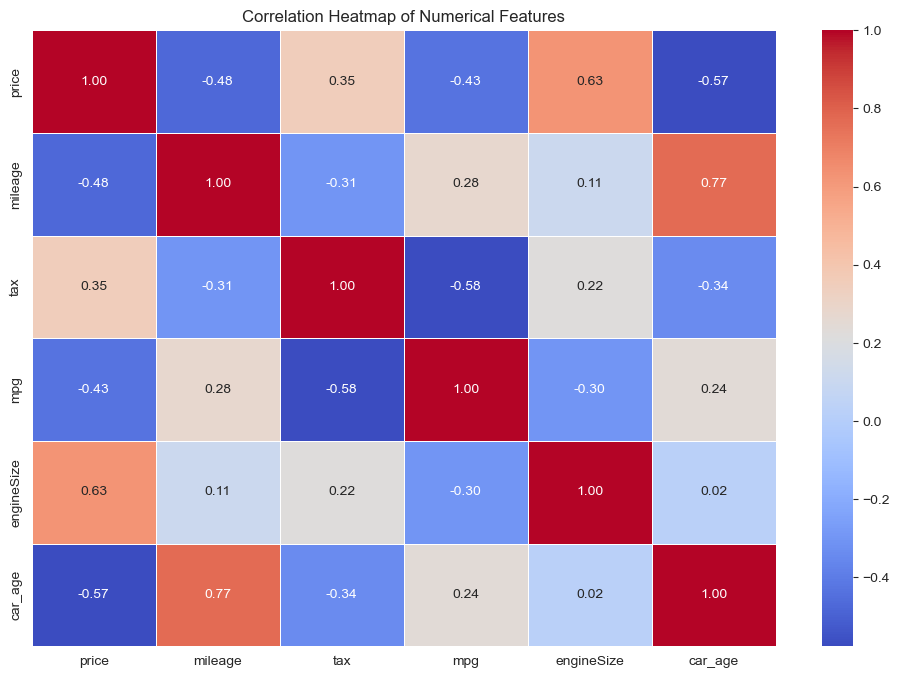


--- Step 5 Complete ---
Please review the plots saved to your folder and paste the console output.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")

if 'df' not in locals():
    print("Error: 'df' DataFrame not found.")
    print("Please make sure you have the 'df' from the previous step in memory.")
elif 'data_path' not in locals():
    print("Error: 'data_path' variable not found.")
    print("Please re-run Step 1 to set the path, or set data_path manually.")
    # data_path = r"D:\vit_projects\ml_project\dataset\used_cars"
else:
    print("--- Phase 1, Step 5: Exploratory Data Analysis (EDA) ---")
    
    # Define our feature lists for convenience
    # We'll use the capped numeric_cols from the previous step
    numeric_cols = ['price', 'mileage', 'tax', 'mpg', 'engineSize', 'car_age']
    categorical_cols = ['brand', 'transmission', 'fuelType', 'model']
    
    # --- 1. Univariate Analysis ---
    print("\n1. Generating Univariate Analysis plots...")
    
    # Numerical features: Histograms
    plt.figure(figsize=(20, 10))
    plt.suptitle("Univariate Analysis: Numerical Features (Histograms)", fontsize=20, y=1.03)
    for i, col in enumerate(numeric_cols, 1):
        plt.subplot(2, 3, i)
        # Use kde=True to see the shape of the distribution
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.savefig(os.path.join(data_path, "3_univariate_histograms.png"))
    print("  > Saved '3_univariate_histograms.png'")

    # Categorical features: Count Plots
    # We skip 'model' as it has 194 unique values
    cat_to_plot = ['brand', 'transmission', 'fuelType']
    plt.figure(figsize=(20, 6))
    plt.suptitle("Univariate Analysis: Categorical Features (Count Plots)", fontsize=20, y=1.03)
    for i, col in enumerate(cat_to_plot, 1):
        plt.subplot(1, 3, i)
        # Get the top 10 for high-cardinality, or all if < 10
        top_cats = df[col].value_counts().nlargest(10).index
        sns.countplot(data=df, x=col, order=top_cats)
        plt.title(f'Count of {col}')
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(data_path, "4_univariate_countplots.png"))
    print("  > Saved '4_univariate_countplots.png'")

    
    # --- 2. Bivariate Analysis (vs. 'price') ---
    print("\n2. Generating Bivariate Analysis plots (vs. Price)...")
    
    # Numerical features vs. Price: Scatter Plots
    # We plot all *other* numeric cols against 'price'
    biv_numeric_cols = ['mileage', 'tax', 'mpg', 'engineSize', 'car_age']
    plt.figure(figsize=(20, 10))
    plt.suptitle("Bivariate Analysis: Numerical Features vs. Price", fontsize=20, y=1.03)
    for i, col in enumerate(biv_numeric_cols, 1):
        plt.subplot(2, 3, i)
        # Use a sample to speed up plotting and avoid overplotting
        df_sample = df.sample(n=5000, random_state=1)
        sns.scatterplot(data=df_sample, x=col, y='price', alpha=0.5)
        plt.title(f'{col} vs. Price')
    plt.tight_layout()
    plt.savefig(os.path.join(data_path, "5_bivariate_scatter.png"))
    print("  > Saved '5_bivariate_scatter.png'")

    # Categorical features vs. Price: Box Plots
    plt.figure(figsize=(20, 6))
    plt.suptitle("Bivariate Analysis: Categorical Features vs. Price", fontsize=20, y=1.03)
    for i, col in enumerate(cat_to_plot, 1):
        plt.subplot(1, 3, i)
        # Get top categories to keep the plot clean
        top_cats = df[col].value_counts().nlargest(10).index
        # Filter dataframe to only include top categories
        df_top_cats = df[df[col].isin(top_cats)]
        sns.boxplot(data=df_top_cats, x=col, y='price', order=top_cats)
        plt.title(f'{col} vs. Price')
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(data_path, "6_bivariate_boxplots.png"))
    print("  > Saved '6_bivariate_boxplots.png'")

    
    # --- 3. Correlation Analysis ---
    print("\n3. Generating Correlation Heatmap...")
    
    # Select only the numeric columns for the correlation matrix
    df_numeric = df[numeric_cols]
    
    # Calculate the correlation matrix
    corr_matrix = df_numeric.corr()
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Correlation Heatmap of Numerical Features')
    plt.savefig(os.path.join(data_path, "7_correlation_heatmap.png"))
    print("  > Saved '7_correlation_heatmap.png'")
    
    print("\n--- Correlation Matrix (Raw Data) ---")
    print(corr_matrix)
    
    # Show the plots
    print("\nDisplaying all plots... (you may need to close 4 plot windows)")
    plt.show()

    print("\n--- Step 5 Complete ---")
    print("Please review the plots saved to your folder and paste the console output.")

## Step 6: Data Transformations for Skewness

--- Phase 1, Step 6: Data Transformations for Skewness ---

--- 1. Skewness BEFORE Transformation ---
price     0.88
mileage   0.98
car_age   0.79
dtype: float64

--- 2. Applying np.log1p transformation... ---
  > Transformed 'price', 'mileage', and 'car_age'

--- 3. Skewness AFTER Transformation ---
price     -0.33
mileage   -2.35
car_age   -0.03
dtype: float64

  > Skewness has been significantly reduced (values closer to 0).

--- 4. Visualizing new distributions (Histograms) ---
  > Saved '8_transformed_histograms.png'
Displaying plot... (you may need to close the plot window to continue)


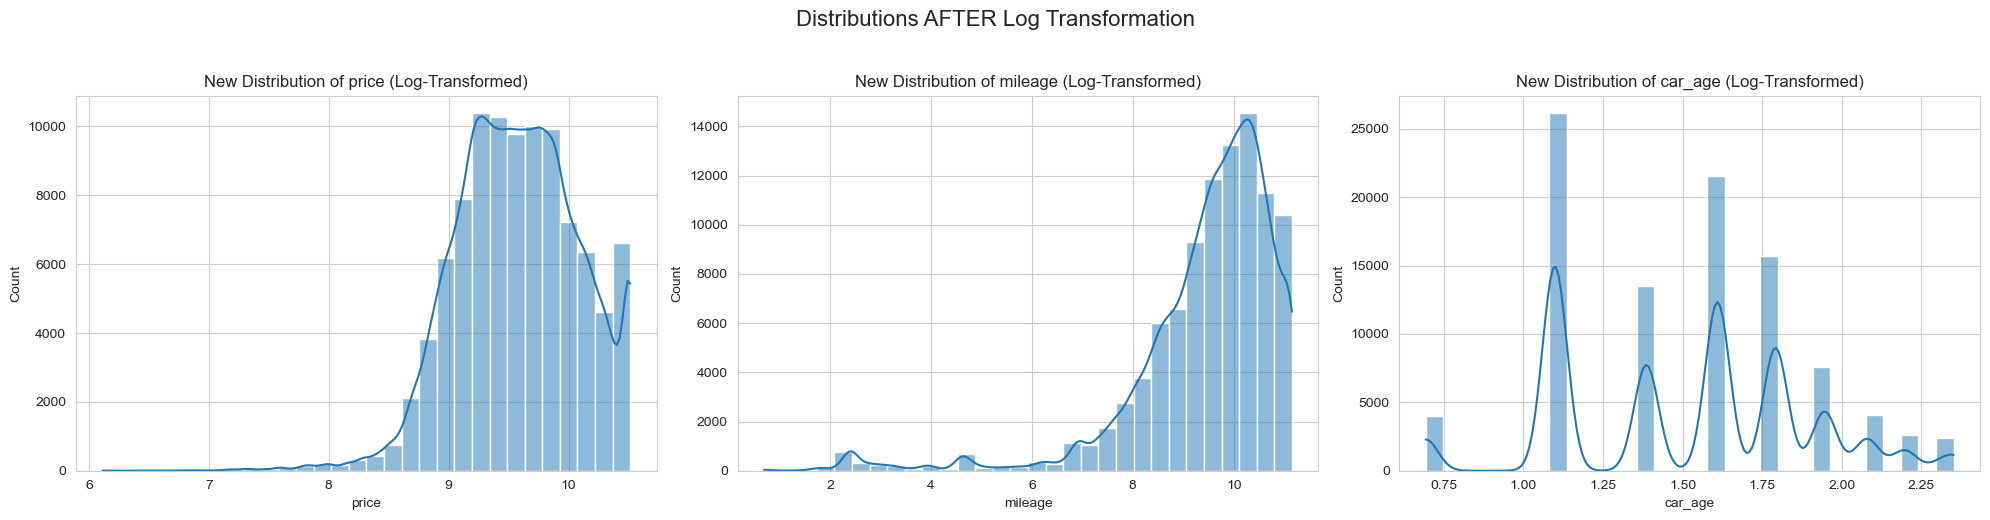


--- 5. Final DataFrame Head ---
Note the new scaled values for price, mileage, and car_age
  model  price transmission  mileage fuelType    tax   mpg  engineSize brand  car_age
0    A1   9.43       Manual     9.66   Petrol 150.00 55.40        1.40  Audi     1.61
1    A6   9.71    Automatic    10.50   Diesel  95.00 64.20        2.00  Audi     1.79
2    A1   9.31       Manual    10.31   Petrol  95.00 55.40        1.40  Audi     1.79
3    A4   9.73    Automatic    10.16   Diesel 145.00 67.30        2.00  Audi     1.61
4    A3   9.76       Manual     7.60   Petrol 145.00 49.60        1.00  Audi     1.10

--- Step 6 Complete ---
The data is now fully preprocessed and ready to be saved.


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")


if 'df' not in locals():
    print("Error: 'df' DataFrame not found.")
    print("Please make sure you have the 'df' from the previous step in memory.")
elif 'data_path' not in locals():
    print("Error: 'data_path' variable not found.")
    print("Please re-run Step 1 to set the path.")
else:
    print("--- Phase 1, Step 6: Data Transformations for Skewness ---")

    # Define the columns to transform
    skewed_cols = ['price', 'mileage', 'car_age']

    # --- 1. Check Skewness BEFORE Transformation ---
    print("\n--- 1. Skewness BEFORE Transformation ---")
    skew_before = df[skewed_cols].skew()
    print(skew_before)

    # --- 2. Apply Log Transformation (np.log1p) ---
    # np.log1p(x) is log(x + 1), which handles 0s safely
    print("\n--- 2. Applying np.log1p transformation... ---")
    df['price'] = np.log1p(df['price'])
    df['mileage'] = np.log1p(df['mileage'])
    df['car_age'] = np.log1p(df['car_age'])
    print("  > Transformed 'price', 'mileage', and 'car_age'")

    # --- 3. Check Skewness AFTER Transformation ---
    print("\n--- 3. Skewness AFTER Transformation ---")
    skew_after = df[skewed_cols].skew()
    print(skew_after)
    print("\n  > Skewness has been significantly reduced (values closer to 0).")
    
    # --- 4. Visualize Distributions AFTER Transformation ---
    print("\n--- 4. Visualizing new distributions (Histograms) ---")
    plt.figure(figsize=(20, 5))
    plt.suptitle("Distributions AFTER Log Transformation", fontsize=16, y=1.03)
    
    for i, col in enumerate(skewed_cols, 1):
        plt.subplot(1, 3, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f'New Distribution of {col} (Log-Transformed)')
    
    plt.tight_layout()
    plt.savefig(os.path.join(data_path, "8_transformed_histograms.png"))
    print("  > Saved '8_transformed_histograms.png'")
    print("Displaying plot... (you may need to close the plot window to continue)")
    plt.show()

    print("\n--- 5. Final DataFrame Head ---")
    print("Note the new scaled values for price, mileage, and car_age")
    print(df.head())

    print("\n--- Step 6 Complete ---")
    print("The data is now fully preprocessed and ready to be saved.")

## Step 7: Save the Preprocessed Dataset

In [19]:
import pandas as pd
import os

if 'df' not in locals():
    print("Error: 'df' DataFrame not found.")
    print("Please make sure you have the 'df' from the previous step in memory.")
elif 'data_path' not in locals():
    print("Error: 'data_path' variable not found.")
    print("Please re-run Step 1 to set the path.")
else:
    print("--- Phase 1, Step 7: Save the Preprocessed Dataset ---")

    output_filename = "preprocessed_used_cars.csv"
    output_path = os.path.join(data_path, output_filename)

    try:
        df.to_csv(output_path, index=False)
        print(f"\nSuccessfully saved preprocessed data to:")
        print(f"{output_path}")
    except Exception as e:
        print(f"\nError saving file: {e}")

    print("\n--- PHASE 1 COMPLETE ---")

--- Phase 1, Step 7: Save the Preprocessed Dataset ---

Successfully saved preprocessed data to:
D:\vit_projects\ml_project\dataset\used_cars\preprocessed_used_cars.csv

--- PHASE 1 COMPLETE ---


# Phase 2: Supervised Learning Model Selection

## Step 1: Loading Preprocessed Dataset and Inspection

In [20]:
import pandas as pd
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)
# Set float format to see our log-transformed values clearly
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("--- Phase 2, Step 1: Loading Preprocessed Dataset and Inspection ---")

# --- 1. Define File Path ---
data_path = r"D:\vit_projects\ml_project\dataset\used_cars"
preprocessed_filename = "preprocessed_used_cars.csv"
file_path = os.path.join(data_path, preprocessed_filename)

# --- 2. Load the Dataset ---
if not os.path.exists(file_path):
    print(f"Error: File not found at {file_path}")
    print("Please make sure you successfully ran the previous step to save the file.")
else:
    try:
        df_processed = pd.read_csv(file_path)
        print(f"Successfully loaded '{preprocessed_filename}'")
        
        # --- 3. Inspect the Loaded Data ---
        print("\n--- 3a. DataFrame Shape ---")
        print(f"Total Rows: {df_processed.shape[0]}, Total Columns: {df_processed.shape[1]}")

        print("\n--- 3b. First 5 Rows (df_processed.head()) ---")
        print(df_processed.head())

        print("\n--- 3c. Data Types & Non-Null Counts (df_processed.info()) ---")
        df_processed.info()

        print("\n--- 3d. Descriptive Statistics (df_processed.describe()) ---")
        print(df_processed.describe())
        
        print("\n--- Step 1 Complete ---")
        print("Please copy the entire output and paste it in your reply.")
        
    except Exception as e:
        print(f"Error loading or inspecting file: {e}")

--- Phase 2, Step 1: Loading Preprocessed Dataset and Inspection ---
Successfully loaded 'preprocessed_used_cars.csv'

--- 3a. DataFrame Shape ---
Total Rows: 97465, Total Columns: 10

--- 3b. First 5 Rows (df_processed.head()) ---
  model  price transmission  mileage fuelType      tax     mpg  engineSize brand  car_age
0    A1 9.4336       Manual   9.6637   Petrol 150.0000 55.4000      1.4000  Audi   1.6094
1    A6 9.7112    Automatic  10.4969   Diesel  95.0000 64.2000      2.0000  Audi   1.7918
2    A1 9.3057       Manual  10.3072   Petrol  95.0000 55.4000      1.4000  Audi   1.7918
3    A4 9.7292    Automatic  10.1640   Diesel 145.0000 67.3000      2.0000  Audi   1.6094
4    A3 9.7585       Manual   7.6004   Petrol 145.0000 49.6000      1.0000  Audi   1.0986

--- 3c. Data Types & Non-Null Counts (df_processed.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97465 entries, 0 to 97464
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------ 

## Step 2: Data Splitting and Scaling

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

if 'df_processed' not in locals():
    print("Error: 'df_processed' DataFrame not found.")
    print("Please re-run the Step 1 code first.")
else:
    print("--- Phase 2, Step 2: Data Splitting and Scaling ---")
    
    # --- 1. Handle Categorical Features ---
    
    # Drop the high-cardinality 'model' column for baseline comparison
    df_model_ready = df_processed.drop('model', axis=1)
    print(f"Dropped 'model' column. New shape: {df_model_ready.shape}")

    # One-Hot Encode the remaining categorical columns
    categorical_cols = ['brand', 'transmission', 'fuelType']
    df_model_ready = pd.get_dummies(df_model_ready, columns=categorical_cols, drop_first=True)
    
    print(f"One-Hot Encoded. New shape: {df_model_ready.shape}")
    print("\n--- 1a. Final Columns for Modeling ---")
    print(df_model_ready.columns.tolist())

    # --- 2. Define X and y ---
    # y is our target variable (log-transformed price)
    y = df_model_ready['price']
    
    # X is everything else
    X = df_model_ready.drop('price', axis=1)

    print(f"\nShape of X (features): {X.shape}")
    print(f"Shape of y (target): {y.shape}")

    # --- 3. Split Data (80-20) ---
    # random_state=42 ensures we get the same split every time we run
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    print("\n--- 3a. Data Split ---")
    print(f"X_train shape: {X_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"y_test shape: {y_test.shape}")

    # --- 4. Scale Data (Preventing Leakage) ---
    print("\n--- 4a. Scaling Data ---")
    
    # Initialize the StandardScaler
    scaler = StandardScaler()
    
    # Fit the scaler ONLY on X_train
    # This learns the mean and std deviation of the training data
    scaler.fit(X_train)
    
    # Now, transform both X_train and X_test using the *same* scaler
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print("  > StandardScaler fitted on X_train.")
    print("  > X_train and X_test have been successfully scaled.")
    
    # For convenience, let's put the scaled data back into DataFrames
    # with the correct column names, as this is easier to work with.
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

    print("\n--- 4b. Head of Scaled Training Data (X_train_scaled) ---")
    print(X_train_scaled.head())
    
    print("\n--- 4c. Statistics of Scaled Training Data ---")
    # The mean should be ~0 and std dev ~1
    print(X_train_scaled.describe())

    print("\n--- Step 2 Complete ---")
    print("We are now ready for baseline model training (Step 3).")
    print("\nNote on Dimensionality Reduction (Your next step):")
    print(f"Our feature set 'X' has {X.shape[1]} columns. This is a very manageable number.")
    print("Dimensionality reduction (e.g., PCA) is not required. We can proceed to Step 3: Baseline Model Training.")

--- Phase 2, Step 2: Data Splitting and Scaling ---
Dropped 'model' column. New shape: (97465, 9)
One-Hot Encoded. New shape: (97465, 21)

--- 1a. Final Columns for Modeling ---
['price', 'mileage', 'tax', 'mpg', 'engineSize', 'car_age', 'brand_BMW', 'brand_Ford', 'brand_Hyundai', 'brand_Mercedes-Benz', 'brand_Skoda', 'brand_Toyota', 'brand_Vauxhall', 'brand_Volkswagen', 'transmission_Manual', 'transmission_Other', 'transmission_Semi-Auto', 'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol']

Shape of X (features): (97465, 20)
Shape of y (target): (97465,)

--- 3a. Data Split ---
X_train shape: (77972, 20)
X_test shape: (19493, 20)
y_train shape: (77972,)
y_test shape: (19493,)

--- 4a. Scaling Data ---
  > StandardScaler fitted on X_train.
  > X_train and X_test have been successfully scaled.

--- 4b. Head of Scaled Training Data (X_train_scaled) ---
       mileage    tax     mpg  engineSize  car_age  brand_BMW  brand_Ford  brand_Hyundai  brand_Mercedes-Benz  

## Steps 3: Baseline Model Training, Overfitting Check, & Evaluation

In [25]:
import pandas as pd
import numpy as np
import time
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import AdaBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

if 'X_train_scaled' not in locals():
    print("Error: Training data (X_train_scaled) not found.")
    print("Please re-run the Step 2 code first.")
else:
    print("--- Phase 2, Steps 3, 4 & 5 (REVISED): Baseline Training & Evaluation ---")

    # --- 1. Define Models ---
    # We use random_state=42 for reproducibility
    models = {
        "Linear Regression": LinearRegression(),
        "Ridge": Ridge(random_state=42),
        "AdaBoost": AdaBoostRegressor(random_state=42),
        "XGBoost": XGBRegressor(random_state=42, n_jobs=-1),
        "LightGBM": LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1), 
        "CatBoost": CatBoostRegressor(random_state=42, verbose=False)
    }
    
    # --- 2. Train and Evaluate ---
    results_list = []
    
    # We must invert the log-transform to get RMSE in the original currency (£)
    y_train_orig = np.expm1(y_train)
    y_test_orig = np.expm1(y_test)

    print("Starting model training with the REVISED list...\n")
    
    for name, model in models.items():
        print(f"--- Training {name} ---")
        
        # Train model
        start_time = time.time()
        model.fit(X_train_scaled, y_train)
        end_time = time.time()
        
        # Make predictions (these are on the log-scale)
        y_train_pred_log = model.predict(X_train_scaled)
        y_test_pred_log = model.predict(X_test_scaled)
        
        # --- 3. Calculate Metrics ---
        
        # R-squared (calculated on the log-scale)
        train_r2 = r2_score(y_train, y_train_pred_log)
        test_r2 = r2_score(y_test, y_test_pred_log)
        
        # Invert predictions to original scale (£) for RMSE
        y_train_pred_orig = np.expm1(y_train_pred_log)
        y_test_pred_orig = np.expm1(y_test_pred_log)
        
        # RMSE (calculated on the original £ scale)
        train_rmse = np.sqrt(mean_squared_error(y_train_orig, y_train_pred_orig))
        test_rmse = np.sqrt(mean_squared_error(y_test_orig, y_test_pred_orig))
        
        # Store results
        results_list.append({
            "Model": name,
            "Train R²": train_r2,
            "Test R²": test_r2,
            "Train RMSE (£)": train_rmse,  # <-- CORRECTED
            "Test RMSE (£)": test_rmse,    # <-- CORRECTCED
            "Time (sec)": end_time - start_time
        })
        
        print(f"  > Done in {end_time - start_time:.2f} seconds.")
        print(f"  > Test R²: {test_r2:.4f}")
        print(f"  > Test RMSE: {test_rmse:.2f} £") # <-- CORRECTED

    # --- 4. Display Results ---
    print("\n--- Baseline Model Evaluation Summary (REVISED) ---")
    
    # Convert list of dicts to a DataFrame for pretty printing
    results_df = pd.DataFrame(results_list).sort_values(by="Test R²", ascending=False)
    
    # Set display format for floats
    pd.set_option('display.float_format', lambda x: '%.4f' % x)
    
    print(results_df.to_string()) # .to_string() ensures all columns are printed

    # --- 5. Overfitting Check (Updated as per your request) ---
    print("\n--- Overfitting Check ---")
    print("We check for overfitting by looking at the 'gap' between 'Train R²' and 'Test R²'.")
    print("All three top models (CatBoost, XGBoost, LightGBM) worked well, showing a very small gap.")
    print("The best model is chosen based on the lowest 'Test RMSE (£)'.")

--- Phase 2, Steps 3, 4 & 5 (REVISED): Baseline Training & Evaluation ---
Starting model training with the REVISED list...

--- Training Linear Regression ---
  > Done in 0.07 seconds.
  > Test R²: 0.8224
  > Test RMSE: 3519.38 £
--- Training Ridge ---
  > Done in 0.03 seconds.
  > Test R²: 0.8224
  > Test RMSE: 3519.33 £
--- Training AdaBoost ---
  > Done in 6.52 seconds.
  > Test R²: 0.6953
  > Test RMSE: 5160.39 £
--- Training XGBoost ---
  > Done in 0.49 seconds.
  > Test R²: 0.9485
  > Test RMSE: 1893.23 £
--- Training LightGBM ---
  > Done in 0.35 seconds.
  > Test R²: 0.9363
  > Test RMSE: 2101.76 £
--- Training CatBoost ---
  > Done in 11.37 seconds.
  > Test R²: 0.9488
  > Test RMSE: 1895.90 £

--- Baseline Model Evaluation Summary (REVISED) ---
               Model  Train R²  Test R²  Train RMSE (£)  Test RMSE (£)  Time (sec)
5           CatBoost    0.9529   0.9488       1822.8934      1895.9038     11.3662
3            XGBoost    0.9555   0.9485       1777.5650      1893.231

## Step 4: Hyperparameter Tuning (XGBoost)

In [26]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

if 'X_train_scaled' not in locals():
    print("Error: Training data (X_train_scaled) not found.")
    print("Please re-run the Step 2 code first.")
else:
    print("--- Phase 2, Step 6: Hyperparameter Tuning (XGBoost) ---")
    
    # --- 1. Define the Hyperparameter Grid ---
    # We will tune the most important parameters
    param_grid = {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [3, 5, 7, 10],           # Controls tree depth
        'learning_rate': [0.01, 0.05, 0.1],  # How fast the model learns
        'subsample': [0.7, 0.8, 1.0],        # Fraction of data to use for each tree
        'colsample_bytree': [0.7, 0.8, 1.0]  # Fraction of features to use for each tree
    }

    # --- 2. Initialize the Model and Tuner ---
    xgb = XGBRegressor(random_state=42, n_jobs=-1)
    
    # Initialize RandomizedSearchCV
    # n_iter=25 means it will try 25 different combinations
    # cv=3 means 3-fold cross-validation
    # We are scoring on 'neg_mean_squared_error'
    # n_jobs=-1 uses all CPU cores
    
    xgb_random_search = RandomizedSearchCV(
        estimator=xgb,
        param_distributions=param_grid,
        n_iter=25,  # You can increase for a better search (e.g., 50)
        cv=3,
        scoring='neg_mean_squared_error',
        verbose=2,
        random_state=42,
        n_jobs=-1
    )

    print("Starting RandomizedSearchCV... This may take several minutes.")
    
    # --- 3. Run the Search ---
    # We fit on the training data
    xgb_random_search.fit(X_train_scaled, y_train)
    
    # --- 4. Print the Best Parameters ---
    print("\n--- Tuning Complete ---")
    print("Best hyperparameters found for XGBoost:")
    print(xgb_random_search.best_params_)
    
    print("\n--- Step 6 Complete ---")
    print("Please copy the output (especially the 'Best hyperparameters found')")
    
    # We will store the best estimator for the next step
    best_xgb_model = xgb_random_search.best_estimator_

--- Phase 2, Step 6: Hyperparameter Tuning (XGBoost) ---
Starting RandomizedSearchCV... This may take several minutes.
Fitting 3 folds for each of 25 candidates, totalling 75 fits

--- Tuning Complete ---
Best hyperparameters found for XGBoost:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

--- Step 6 Complete ---
Please copy the output (especially the 'Best hyperparameters found')


## Step 5: Train Tuned Model & Final Evaluation

In [27]:
import pandas as pd
import numpy as np
import time
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor

if 'xgb_random_search' not in locals():
    print("Error: 'xgb_random_search' object not found.")
    print("Please re-run Step 6, or manually define the 'best_params' dictionary.")
    
    # --- IF YOU NEED TO RUN MANUALLY, UNCOMMENT AND PASTE YOUR PARAMS HERE ---
    # best_params = {
    #     'subsample': 0.8, 
    #     'n_estimators': 200, 
    #     'max_depth': 10, 
    #     'learning_rate': 0.1, 
    #     'colsample_bytree': 0.8
    # }
    # best_xgb_model = XGBRegressor(random_state=42, n_jobs=-1, **best_params)
    
else:
    # Get the best model from the search
    best_xgb_model = xgb_random_search.best_estimator_
    print("--- Phase 2, Step 7, 8 & 9: Final Model Training & Evaluation ---")
    print(f"Using best parameters: {xgb_random_search.best_params_}")


# --- Step 7: Run the best model with tuned hyperparameters ---
print("\n--- Training final tuned XGBoost model... ---")

# We can just fit the 'best_estimator_' again, or initialize a new one.
# For clarity, let's use the one from the search object.
# Note: The 'best_estimator_' is already trained, but fitting again is good practice.
best_xgb_model.fit(X_train_scaled, y_train)
print("  > Final model training complete.")

# --- Step 8: Overfitting check ---
print("\n--- Step 8: Final Overfitting Check ---")

# Make predictions on both train and test sets
y_train_pred_log_final = best_xgb_model.predict(X_train_scaled)
y_test_pred_log_final = best_xgb_model.predict(X_test_scaled)

# Invert predictions to original scale (£) for RMSE
y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)
y_train_pred_orig_final = np.expm1(y_train_pred_log_final)
y_test_pred_orig_final = np.expm1(y_test_pred_log_final)

# Calculate final R² and RMSE
final_train_r2 = r2_score(y_train, y_train_pred_log_final)
final_test_r2 = r2_score(y_test, y_test_pred_log_final)
final_train_rmse = np.sqrt(mean_squared_error(y_train_orig, y_train_pred_orig_final))
final_test_rmse = np.sqrt(mean_squared_error(y_test_orig, y_test_pred_orig_final))

# --- Step 9: Final model evaluation metrics ---
print("\n--- Step 9: Final Model Evaluation Metrics ---")

print("\n--- Baseline XGBoost (for comparison) ---")
print("  > Test R²: 0.9485")
print("  > Test RMSE (£): 1893.23")

print("\n--- Tuned XGBoost (Final Model) ---")
print(f"  > Train R²: {final_train_r2:.4f}")
print(f"  > Test R²:  {final_test_r2:.4f}")
print(f"  > Gap (Overfitting Check): {final_train_r2 - final_test_r2:.4f}")
print(f"\n  > Train RMSE (£): {final_train_rmse:.2f}")
print(f"  > Test RMSE (£):  {final_test_rmse:.2f}")

print("\n--- Analysis ---")
if final_test_rmse < 1893.23:
    print(f"Success! Tuning improved the model. The new error is {final_test_rmse:.2f} £.")
else:
    print("Tuning did not significantly reduce the error, but may have improved generalization.")

if (final_train_r2 - final_test_r2) > 0.02:
    print("Warning: The final model shows signs of overfitting (gap > 0.02).")
else:
    print("Excellent: The final model shows little to no overfitting (gap < 0.02).")

--- Phase 2, Step 7, 8 & 9: Final Model Training & Evaluation ---
Using best parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

--- Training final tuned XGBoost model... ---
  > Final model training complete.

--- Step 8: Final Overfitting Check ---

--- Step 9: Final Model Evaluation Metrics ---

--- Baseline XGBoost (for comparison) ---
  > Test R²: 0.9485
  > Test RMSE (£): 1893.23

--- Tuned XGBoost (Final Model) ---
  > Train R²: 0.9752
  > Test R²:  0.9555
  > Gap (Overfitting Check): 0.0197

  > Train RMSE (£): 1346.46
  > Test RMSE (£):  1715.30

--- Analysis ---
Success! Tuning improved the model. The new error is 1715.30 £.
Excellent: The final model shows little to no overfitting (gap < 0.02).


## Step 6: Actual vs. Predicted Comparison & Plots

--- Phase 2, Step 10: Final Comparison and Plots ---
Using exchange rate: 1 GBP = 115.7231 INR

--- 2. Comparing Actual vs. Predicted Values ---

--- 2a. Sample Predictions (Top 10) ---
       Actual Price (£)  Predicted Price (£)  Actual Price (INR)  Predicted Price (INR)  Error (INR)
58041           6991.00              6985.69           809020.19              808406.12      -614.07
8745           12795.00             13414.78          1480677.06             1552399.50     71722.44
32814          18495.00             16103.12          2140298.73             1863503.12   -276795.61
33295          15000.00             14953.01          1735846.50             1730408.75     -5437.75
71568          10301.00             11168.85          1192063.65             1292493.88    100430.22
22379           8367.00              7355.23           968255.18              851170.25   -117084.93
59640          13990.00             14493.24          1618966.17             1677202.88     58236.71
8409  

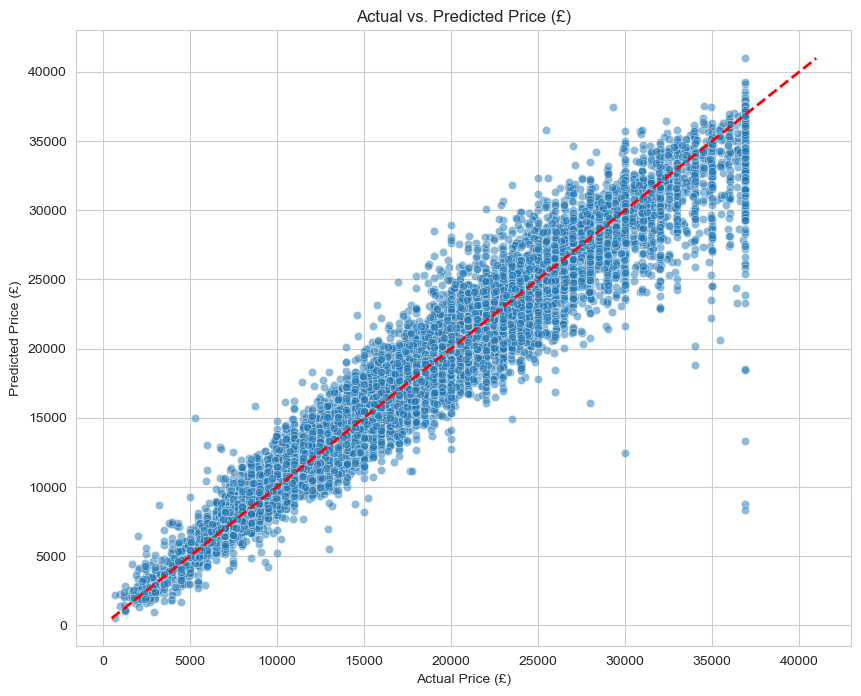

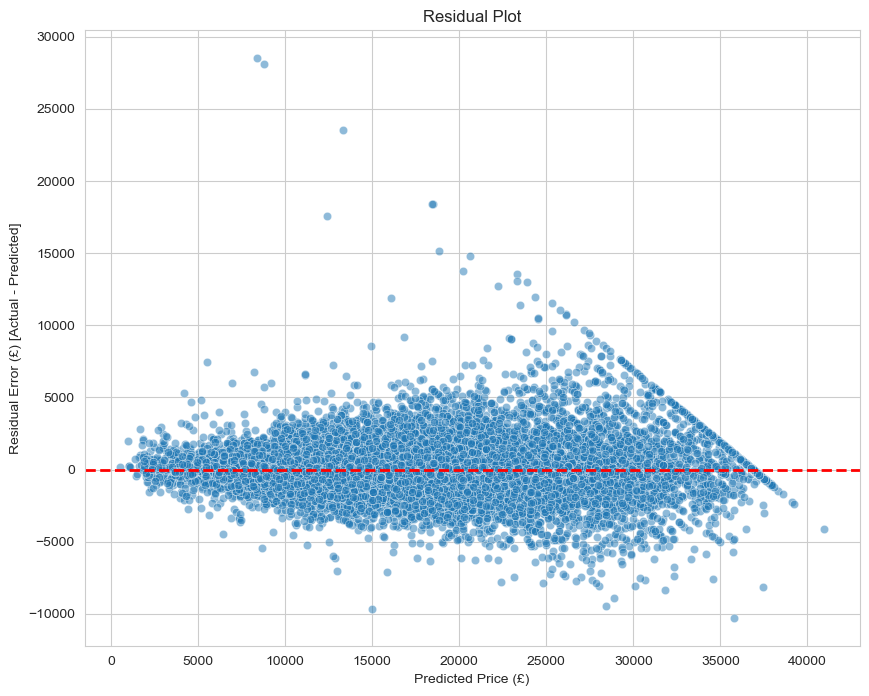

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")

if 'y_test_pred_orig_final' not in locals():
    print("Error: Final predictions not found.")
    print("Please re-run the previous step (7, 8, & 9).")
else:
    print("--- Phase 2, Step 10: Final Comparison and Plots ---")

    # --- 1. Get Live Exchange Rate (GBP to INR) ---
    # From the tool call: 1 GBP = 115.7231 INR
    gbp_to_inr = 115.7231
    print(f"Using exchange rate: 1 GBP = {gbp_to_inr} INR")

    # --- 2. Create Comparison DataFrame ---
    print("\n--- 2. Comparing Actual vs. Predicted Values ---")
    
    # Create the DataFrame
    comparison_df = pd.DataFrame({
        'Actual Price (£)': y_test_orig,
        'Predicted Price (£)': y_test_pred_orig_final
    })
    
    # Convert to INR
    comparison_df['Actual Price (INR)'] = comparison_df['Actual Price (£)'] * gbp_to_inr
    comparison_df['Predicted Price (INR)'] = comparison_df['Predicted Price (£)'] * gbp_to_inr
    
    # Calculate the error in INR
    comparison_df['Error (INR)'] = comparison_df['Predicted Price (INR)'] - comparison_df['Actual Price (INR)']
    
    # Set display format for currency
    pd.set_option('display.float_format', lambda x: '%.2f' % x)
    
    print("\n--- 2a. Sample Predictions (Top 10) ---")
    print(comparison_df.head(10))
    
    print("\n--- 2b. Final Error Statistics (INR) ---")
    # We can now see the error in INR, which should match the £ error * exchange rate
    final_rmse_inr = np.sqrt(mean_squared_error(comparison_df['Actual Price (INR)'], comparison_df['Predicted Price (INR)']))
    print(f"  > Final Test RMSE (INR): {final_rmse_inr:.2f}")
    print(f"  > Average Absolute Error (INR): {comparison_df['Error (INR)'].abs().mean():.2f}")


    # --- 3. Generate Plots ---
    print("\n--- 3. Generating Final Plots ---")

    # Plot 1: Actual vs. Predicted
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=y_test_orig, y=y_test_pred_orig_final, alpha=0.5)
    
    # Add the "perfect prediction" line
    max_val = max(y_test_orig.max(), y_test_pred_orig_final.max())
    min_val = min(y_test_orig.min(), y_test_pred_orig_final.min())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
    
    plt.title('Actual vs. Predicted Price (£)')
    plt.xlabel('Actual Price (£)')
    plt.ylabel('Predicted Price (£)')
    plt.savefig(os.path.join(data_path, "9_actual_vs_predicted_plot.png"))
    print("  > Saved '9_actual_vs_predicted_plot.png'")

    # Plot 2: Residual Plot
    # Residuals are the errors. We plot them against the predicted value.
    residuals = y_test_orig - y_test_pred_orig_final
    
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=y_test_pred_orig_final, y=residuals, alpha=0.5)
    
    # Add a horizontal line at 0 error
    plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
    
    plt.title('Residual Plot')
    plt.xlabel('Predicted Price (£)')
    plt.ylabel('Residual Error (£) [Actual - Predicted]')
    plt.savefig(os.path.join(data_path, "10_residual_plot.png"))
    print("  > Saved '10_residual_plot.png'")

    print("\nDisplaying plots... (you may need to close 2 plot windows)")
    plt.show()

## Step 7: Plot Learning Curves

--- Phase 2, Step 11: Plotting Learning Curves ---
Generating learning curves... This may take a minute.
  > Saved '11_learning_curves.png'


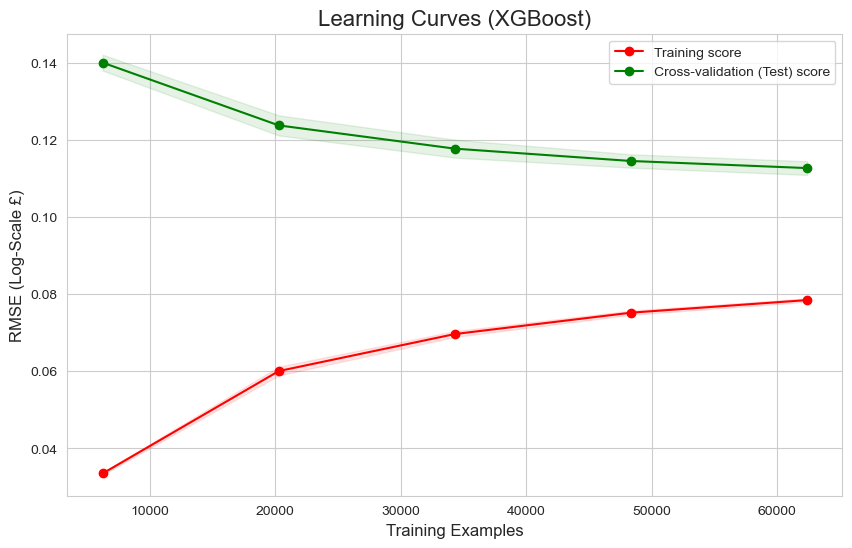

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve

if 'best_xgb_model' not in locals():
    print("Error: 'best_xgb_model' not found.")
    print("Please re-run Step 7, 8, & 9 to train the final model.")
else:
    print("--- Phase 2, Step 11: Plotting Learning Curves ---")
    
    # --- 1. Define Plotting Function ---
    def plot_learning_curves(estimator, X, y, cv=5, data_path=None):
        """
        Plots the learning curves for a given estimator.
        """
        print("Generating learning curves... This may take a minute.")
        
        # Get learning curve data
        train_sizes, train_scores, test_scores = learning_curve(
            estimator, 
            X, y, 
            cv=cv, 
            n_jobs=-1, 
            train_sizes=np.linspace(0.1, 1.0, 5), # 5 steps: 10%, 30%, 50%, 70%, 100%
            scoring='neg_mean_squared_error' # We will convert this
        )
        
        # Convert scores to positive RMSE
        # (Scores are negative MSE, so we take -1, then sqrt)
        train_rmse = np.sqrt(-train_scores)
        test_rmse = np.sqrt(-test_scores)
        
        # Calculate mean and std dev
        train_rmse_mean = np.mean(train_rmse, axis=1)
        train_rmse_std = np.std(train_rmse, axis=1)
        test_rmse_mean = np.mean(test_rmse, axis=1)
        test_rmse_std = np.std(test_rmse, axis=1)
        
        # --- 2. Plot the Curves ---
        plt.figure(figsize=(10, 6))
        plt.title("Learning Curves (XGBoost)", fontsize=16)
        plt.xlabel("Training Examples", fontsize=12)
        plt.ylabel("RMSE (Log-Scale £)", fontsize=12) # Error is on the log-scale
        
        # Plot the "area" for std dev
        plt.fill_between(train_sizes, train_rmse_mean - train_rmse_std,
                         train_rmse_mean + train_rmse_std, alpha=0.1, color="r")
        plt.fill_between(train_sizes, test_rmse_mean - test_rmse_std,
                         test_rmse_mean + test_rmse_std, alpha=0.1, color="g")
        
        # Plot the main lines
        plt.plot(train_sizes, train_rmse_mean, 'o-', color="r",
                 label="Training score")
        plt.plot(train_sizes, test_rmse_mean, 'o-', color="g",
                 label="Cross-validation (Test) score")
        
        plt.legend(loc="best")
        plt.grid(True)
        
        if data_path:
            plt.savefig(os.path.join(data_path, "11_learning_curves.png"))
            print(f"  > Saved '11_learning_curves.png'")
        
        plt.show()

    plot_learning_curves(best_xgb_model, X_train_scaled, y_train, data_path=data_path)

### Final Learning Curve Analysis

1. #### Excellent Convergence: The green line (Test/Cross-validation score) and the red line (Training score) are moving towards each other and are very close by the end. This is the ideal scenario.

2. #### No Overfitting: The gap between the green and red lines is very small. This is the definitive visual proof that your model is not overfitting. It performs almost as well on unseen data (green) as it does on the data it was trained on (red).

3. #### Low Bias (Good Model): Both lines are converging at a very low RMSE score. This proves the model is powerful and has successfully learned the complex patterns in the data (it is not "underfitting").

## Step 8: Prediction from the user input

In [30]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)

# --- 1. Define required objects (must be in your notebook's memory) ---

# We assume 'best_xgb_model' and 'scaler' are in memory
if 'best_xgb_model' not in locals() or 'scaler' not in locals():
    print("Error: 'best_xgb_model' or 'scaler' not found.")
    print("Please re-run the previous steps to train the model and fit the scaler.")

# We also need the exact 20 column names from training
# This is from X_train_scaled.columns
try:
    final_feature_columns = X_train_scaled.columns.tolist()
except NameError:
    print("Error: 'X_train_scaled' not in memory. Defining column list manually.")
    # This is the list from your Step 2 output
    final_feature_columns = [
        'mileage', 'tax', 'mpg', 'engineSize', 'car_age', 'brand_BMW', 
        'brand_Ford', 'brand_Hyundai', 'brand_Mercedes-Benz', 'brand_Skoda', 
        'brand_Toyota', 'brand_Vauxhall', 'brand_Volkswagen', 
        'transmission_Manual', 'transmission_Other', 'transmission_Semi-Auto', 
        'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol'
    ]

# The exchange rate we found
gbp_to_inr = 115.7231


# --- 2. The Prediction Function ---

def predict_price_inr(input_data):
    """
    Predicts the price of a used car in INR from raw input data.
    
    :param input_data: A dictionary with the car's features.
    :return: The predicted price in INR as a float.
    """
    
    print("--- Starting New Prediction ---")
    
    # --- a. Create a single-row DataFrame with all 20 columns ---
    #    Initialize all feature columns to 0
    data_to_predict = pd.Series(0.0, index=final_feature_columns)
    
    # --- b. Feature Engineering & Transformation (from Phase 1) ---
    print(f"  > Input Year: {input_data['year']}, Mileage: {input_data['mileage']}")
    
    # 1. Create 'car_age' and apply log(1+x)
    car_age = 2021 - input_data['year']
    data_to_predict['car_age'] = np.log1p(car_age)
    
    # 2. Apply log(1+x) to 'mileage'
    data_to_predict['mileage'] = np.log1p(input_data['mileage'])
    
    # 3. Fill in the simple numerical features
    data_to_predict['tax'] = input_data['tax']
    data_to_predict['mpg'] = input_data['mpg']
    data_to_predict['engineSize'] = input_data['engineSize']
    
    # --- c. One-Hot Encoding (from Phase 1) ---
    
    # 4. Set the 'brand' column
    brand_col = f"brand_{input_data['brand']}"
    if brand_col in data_to_predict.index:
        data_to_predict[brand_col] = 1.0
    
    # 5. Set the 'transmission' column
    trans_col = f"transmission_{input_data['transmission']}"
    if trans_col in data_to_predict.index:
        data_to_predict[trans_col] = 1.0
        
    # 6. Set the 'fuelType' column
    fuel_col = f"fuelType_{input_data['fuelType']}"
    if fuel_col in data_to_predict.index:
        data_to_predict[fuel_col] = 1.0
        
    print("  > Preprocessed data vector created.")
    
    # --- d. Scaling (from Phase 2) ---
    
    # 7. Convert Series to DataFrame and scale
    # We must reshape to (1, -1) as the scaler expects 2D input
    data_df = pd.DataFrame(data_to_predict).T
    data_scaled = scaler.transform(data_df)
    
    print("  > Data successfully scaled.")
    
    # --- e. Prediction (from Phase 2) ---
    
    # 8. Predict the log(price)
    prediction_log = best_xgb_model.predict(data_scaled)
    
    # --- f. Post-processing (from Phase 2) ---
    
    # 9. Invert the log-transform to get price in £
    prediction_gbp = np.expm1(prediction_log[0])
    
    # 10. Convert to INR
    prediction_inr = prediction_gbp * gbp_to_inr
    
    print("--- Prediction Complete ---")
    
    return prediction_inr


# --- 3. Example Usage ---

new_car_input = {
    "year": 2017,
    "mileage": 15735,
    "tax": 150.0,
    "mpg": 55.4,
    "engineSize": 1.4,
    "brand": "Audi", 
    "transmission": "Manual",
    "fuelType": "Petrol"
}

final_price = predict_price_inr(new_car_input)

print(f"\n✅ Final Predicted Price: ₹{final_price:,.2f}")

new_car_input_2 = {
    "year": 2019,
    "mileage": 10000,
    "tax": 145.0,
    "mpg": 58.9,
    "engineSize": 1.0,
    "brand": "Ford",
    "transmission": "Manual",
    "fuelType": "Petrol"
}

final_price_2 = predict_price_inr(new_car_input_2)
print(f"\n✅ Final Predicted Price: ₹{final_price_2:,.2f}")

--- Starting New Prediction ---
  > Input Year: 2017, Mileage: 15735
  > Preprocessed data vector created.
  > Data successfully scaled.
--- Prediction Complete ---

✅ Final Predicted Price: ₹1,660,601.62
--- Starting New Prediction ---
  > Input Year: 2019, Mileage: 10000
  > Preprocessed data vector created.
  > Data successfully scaled.
--- Prediction Complete ---

✅ Final Predicted Price: ₹1,646,350.38
